In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import plotly.express as px
import plotly.graph_objects as go

weights_canada_path = "data/masks/weights_canada.nc"
weights_prop_precise_path = "data/masks/weights_prop_precise.nc"
temp_path = "data/canada/data_0.nc"

def open_netcdf_with_fallback(path):
    errors = []
    for engine in ("netcdf4", "h5netcdf", "scipy"):
        try:
            return xr.open_dataset(path, engine=engine)
        except Exception as exc:
            errors.append((engine, exc))

    details = "\n".join(
        f"- {engine}: {type(exc).__name__}: {exc}"
        for engine, exc in errors
    )
    raise RuntimeError(
        f"Impossible d'ouvrir {path}.\n"
        "Installe un backend NetCDF dans cet environnement, par exemple:\n"
        "conda install -n quant-regimes-vol -c conda-forge netcdf4 h5netcdf\n"
        "ou\n"
        "pip install netCDF4 h5netcdf\n"
        f"Erreurs d'ouverture:\n{details}"
    )

weights_canada = open_netcdf_with_fallback(weights_canada_path)
weights_prop_precise = open_netcdf_with_fallback(weights_prop_precise_path)
temp = open_netcdf_with_fallback(temp_path)
weights = weights_canada

In [2]:
import importlib
import sys, numpy, xarray

print(sys.executable)
print(sys.version)
print("numpy", numpy.__version__)
print("xarray", xarray.__version__)

for module_name in ("netCDF4", "h5netcdf", "scipy"):
    try:
        module = importlib.import_module(module_name)
        print(module_name, module.__version__)
    except Exception as exc:
        print(module_name, f"non disponible ({type(exc).__name__}: {exc})")


/opt/homebrew/Caskroom/mambaforge/base/envs/quant-regimes-vol/bin/python
3.10.7 | packaged by conda-forge | (main, Nov 21 2022, 13:21:27) [Clang 14.0.6 ]
numpy 2.2.6
xarray 2025.6.1
netCDF4 1.7.4
h5netcdf 1.8.1
scipy 1.15.3


In [3]:
def _extract_weight_array(weights):
    if isinstance(weights, xr.DataArray):
        wt = weights
    elif "final_weights" in weights:
        wt = weights["final_weights"]
    else:
        wt = next(iter(weights.data_vars.values()))

    if "latitude" not in wt.dims or "longitude" not in wt.dims:
        raise ValueError(
            f"Le tableau de poids doit contenir les dimensions latitude/longitude, trouve: {wt.dims}"
        )

    # Reduit toutes les dimensions non spatiales pour obtenir une matrice 2D.
    for dim in list(wt.dims):
        if dim not in {"latitude", "longitude"}:
            wt = wt.isel({dim: 0})

    wt = wt.squeeze(drop=True)
    wt = wt.transpose("latitude", "longitude")
    wt = wt.sortby("latitude")
    wt = wt.sortby("longitude")
    return wt

def visualize_climate_nc(weights, region_name=None):
    da = temp["t2m"]
    da = da - 273.15
    if "year" in da.dims:
        da = da.isel(year=-1)
    elif "valid_time" in da.dims:
        da = da.isel(valid_time=-1)

    da = da.transpose("latitude", "longitude")
    da = da.sortby("latitude")
    da = da.sortby("longitude")

    wt = _extract_weight_array(weights)
    wt = wt.interp(latitude=da.latitude, longitude=da.longitude, method="nearest").fillna(0.0)
    mask = wt > 0

    da_region = da.where(mask).dropna("latitude", how="all").dropna("longitude", how="all")
    if da_region.size == 0:
        raise ValueError("Le masque ne recouvre aucune cellule de la grille temperature.")

    min_temp = float(da.min().item())
    max_temp = float(da.max().item())
    lat_min = float(da_region.latitude.min())
    lat_max = float(da_region.latitude.max())
    lon_min = float(da_region.longitude.min())
    lon_max = float(da_region.longitude.max())

    pad = 0.5
    lat_desc = bool(da_region.latitude.values[0] > da_region.latitude.values[-1])
    lon_desc = bool(da_region.longitude.values[0] > da_region.longitude.values[-1])
    lat_range = [lat_max + pad, lat_min - pad] if lat_desc else [lat_min - pad, lat_max + pad]
    lon_range = [lon_max + pad, lon_min - pad] if lon_desc else [lon_min - pad, lon_max + pad]

    title = f"Carte actuelle des temperatures ({region_name})" if region_name else "Carte actuelle des temperatures"
    fig = px.imshow(
        da_region,
        x=da_region["longitude"],
        y=da_region["latitude"],
        color_continuous_scale="RdBu_r",
        origin="lower",
        title=title,
        labels={"color": "Temp (°C)"},
        range_color=[min_temp, max_temp]
    )
    fig.update_yaxes(scaleanchor="x", scaleratio=1)
    fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False, title=None)
    fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, title=None)
    fig.update_xaxes(range=lon_range, autorange=False)
    fig.update_yaxes(range=lat_range, autorange=False)
    return fig

def visualize_weights(weights, title):
    wt = _extract_weight_array(weights)
    fig = px.imshow(
        wt,
        x=wt["longitude"],
        y=wt["latitude"],
        color_continuous_scale="Viridis",
        origin="lower",
        title=title,
        labels={"color": "Poids"}
    )
    fig.update_yaxes(scaleanchor="x", scaleratio=1)
    fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False, title=None)
    fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, title=None)
    return fig

fig1 = visualize_climate_nc(weights_canada, region_name="Canada")
fig1

fig_weights_canada = visualize_weights(weights_canada, title="Poids - Canada")
fig_weights_canada

In [4]:
fig_weights_prop_precise = visualize_weights(weights_prop_precise, title="Poids - France")
fig_weights_prop_precise

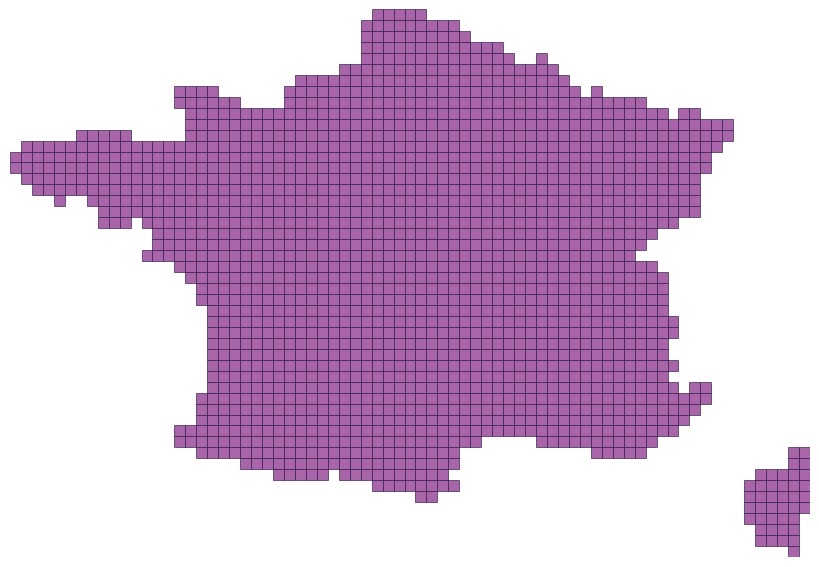

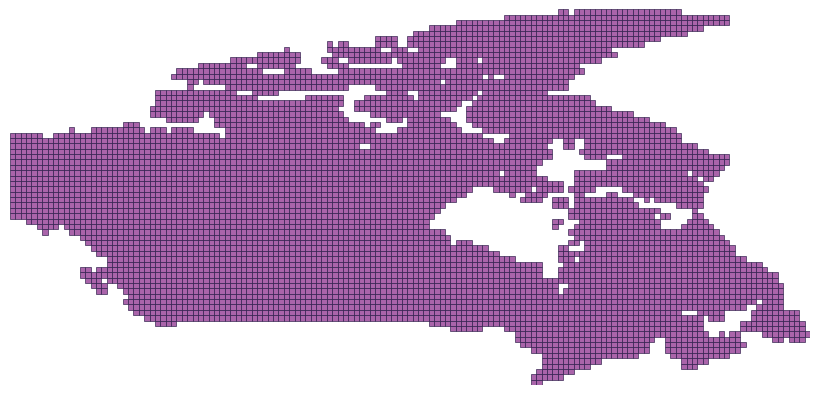

In [5]:
from matplotlib.patches import Rectangle

def _build_blocks(size, step):
    return [(start, min(start + step, size)) for start in range(0, size, step)]

def _coarsen_mask(mask, step):
    if step <= 1:
        row_blocks = _build_blocks(mask.shape[0], 1)
        col_blocks = _build_blocks(mask.shape[1], 1)
        return mask, row_blocks, col_blocks

    row_blocks = _build_blocks(mask.shape[0], step)
    col_blocks = _build_blocks(mask.shape[1], step)
    coarse = np.zeros((len(row_blocks), len(col_blocks)), dtype=bool)

    for bi, (r0, r1) in enumerate(row_blocks):
        for bj, (c0, c1) in enumerate(col_blocks):
            coarse[bi, bj] = np.any(mask[r0:r1, c0:c1])

    return coarse, row_blocks, col_blocks

def plot_country_gridded(
    weights,
    cell_color="#aa64aa",
    grid_color="#291947",
    figsize=(8, 6),
    max_country_cells=6000,
):
    wt = _extract_weight_array(weights)
    mask = wt.values > 0

    lats = wt.latitude.values
    lons = wt.longitude.values
    if lats.size < 2 or lons.size < 2:
        raise ValueError("La grille latitude/longitude doit contenir au moins 2 points par axe.")

    country_cells = int(np.count_nonzero(mask))
    if country_cells == 0:
        raise ValueError("Le masque ne contient aucune cellule du pays.")

    if max_country_cells is None or max_country_cells <= 0:
        step = 1
    else:
        step = max(1, int(np.ceil(np.sqrt(country_cells / max_country_cells))))

    coarse_mask, row_blocks, col_blocks = _coarsen_mask(mask, step)

    lat_step = float(np.median(np.abs(np.diff(lats))))
    lon_step = float(np.median(np.abs(np.diff(lons))))
    lat_edges = np.concatenate(([lats[0] - lat_step / 2], (lats[:-1] + lats[1:]) / 2, [lats[-1] + lat_step / 2]))
    lon_edges = np.concatenate(([lons[0] - lon_step / 2], (lons[:-1] + lons[1:]) / 2, [lons[-1] + lon_step / 2]))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    for bi, bj in np.argwhere(coarse_mask):
        r0, r1 = row_blocks[bi]
        c0, c1 = col_blocks[bj]
        x0, x1 = lon_edges[c0], lon_edges[c1]
        y0, y1 = lat_edges[r0], lat_edges[r1]

        ax.add_patch(
            Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                facecolor=cell_color,
                edgecolor=grid_color,
                linewidth=0.45,
            )
        )

    rows, cols = np.where(coarse_mask)
    cmin0, cmax1 = col_blocks[cols.min()][0], col_blocks[cols.max()][1]
    rmin0, rmax1 = row_blocks[rows.min()][0], row_blocks[rows.max()][1]
    ax.set_xlim(lon_edges[cmin0], lon_edges[cmax1])
    ax.set_ylim(lat_edges[rmin0], lat_edges[rmax1])

    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    return fig, ax

fig_france, _ = plot_country_gridded(weights_prop_precise, max_country_cells=6000)
plt.show()

fig_canada, _ = plot_country_gridded(weights_canada, max_country_cells=6000)
plt.show()
